In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path)

c:\Users\Prajwal\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Prajwal\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1


In [2]:
import os

print(path)

for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs)
    print("Number of files:", len(files))
    print("Files:", files[:5])
    print("-" * 50)

C:\Users\Prajwal\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1
C:\Users\Prajwal\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1
Folders: ['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24', 'audio_speech_actors_01-24']
Number of files: 0
Files: []
--------------------------------------------------
C:\Users\Prajwal\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1\Actor_01
Folders: []
Number of files: 60
Files: ['03-01-01-01-01-01-01.wav', '03-01-01-01-01-02-01.wav', '03-01-01-01-02-01-01.wav', '03-01-01-01-02-02-01.wav', '03-01-02-01-01-01-01.wav']
--------------------------------------------------
C:\Users\Prajwal\.cache\kagglehub\datasets\uwrfkaggler\ravdess

In [3]:
import os
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt

In [4]:
emotion_map = {
    "01": "neutral",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear"
}

In [5]:
filepaths = []
emotions = []

for actor in os.listdir(path):

    actor_path = os.path.join(path, actor)

    if not os.path.isdir(actor_path):
        continue

    for filename in os.listdir(actor_path):

        if not filename.endswith(".wav"):
            continue

        parts = filename.split("-")

        emotion_code = parts[2]

        if emotion_code in emotion_map:

            filepaths.append(
                os.path.join(actor_path, filename)
            )

            emotions.append(
                emotion_map[emotion_code]
            )

In [6]:
metadata = pd.DataFrame({
    "filepath": filepaths,
    "emotion": emotions
})

In [7]:
metadata.head()

,filepath,emotion
0,C:\Users\Prajwal\.cache\kagglehub\datasets\uwr...,neutral
1,C:\Users\Prajwal\.cache\kagglehub\datasets\uwr...,neutral
2,C:\Users\Prajwal\.cache\kagglehub\datasets\uwr...,neutral
3,C:\Users\Prajwal\.cache\kagglehub\datasets\uwr...,neutral
4,C:\Users\Prajwal\.cache\kagglehub\datasets\uwr...,happy


In [8]:
print("Total samples:", len(metadata))

Total samples: 864


In [9]:
print(metadata["emotion"].value_counts())

emotion
happy      192
sad        192
angry      192
fear       192
neutral     96
Name: count, dtype: int64


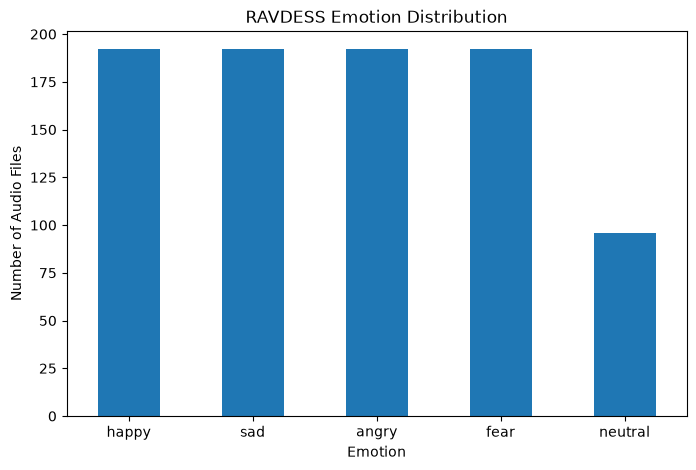

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

metadata["emotion"].value_counts().plot(kind="bar")

plt.title("RAVDESS Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")

plt.xticks(rotation=0)

plt.show()

In [11]:
sample = metadata.iloc[0]

print("File:", sample["filepath"])
print("Emotion:", sample["emotion"])

File: C:\Users\Prajwal\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1\Actor_01\03-01-01-01-01-01-01.wav
Emotion: neutral


In [12]:
import IPython.display as ipd

ipd.Audio(sample["filepath"])

In [13]:
import librosa

signal, sr = librosa.load(
    sample["filepath"],
    sr=None
)

print("Sample rate:", sr)
print("Number of samples:", len(signal))
print("Duration:", len(signal) / sr, "seconds")

Sample rate: 48000
Number of samples: 158558
Duration: 3.3032916666666665 seconds


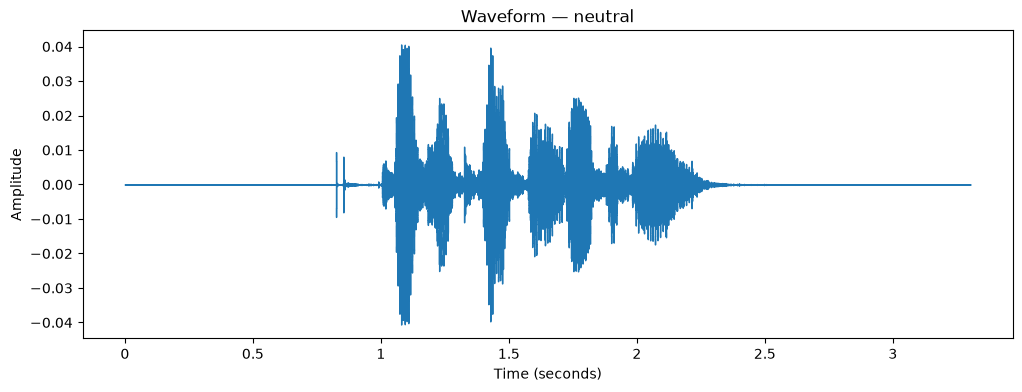

In [14]:
import librosa.display

plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    signal,
    sr=sr
)

plt.title(f"Waveform — {sample['emotion']}")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [15]:
mel = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

In [16]:
mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

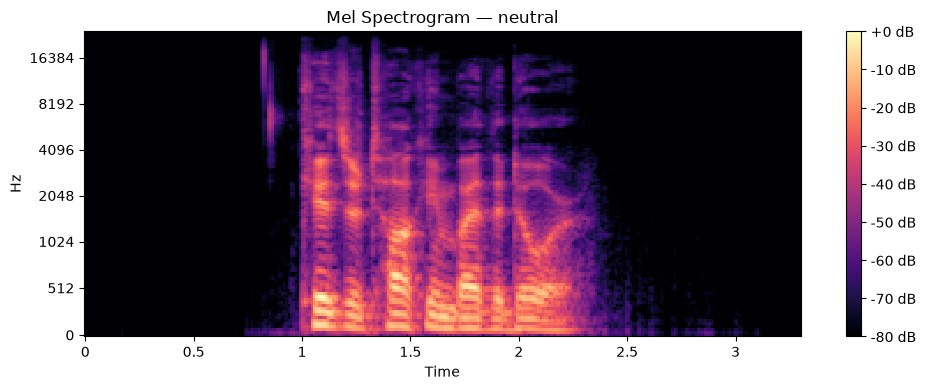

In [17]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title(f"Mel Spectrogram — {sample['emotion']}")

plt.tight_layout()
plt.show()

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader


In [19]:
label_map = {
    "neutral": 0,
    "happy": 1,
    "sad": 2,
    "angry": 3,
    "fear": 4
}

In [20]:
SAMPLE_RATE = 22050
DURATION = 3
NUM_SAMPLES = SAMPLE_RATE * DURATION
class RAVDESSDataset(Dataset):

    def __init__(self, metadata, label_map):
        self.metadata = metadata
        self.label_map = label_map

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):

        # -------------------------
        # Get file and label
        # -------------------------
        audio_path = self.metadata.iloc[index]["filepath"]
        emotion = self.metadata.iloc[index]["emotion"]

        # -------------------------
        # Load audio
        # -------------------------
        signal, sr = librosa.load(
            audio_path,
            sr=SAMPLE_RATE
        )

        # -------------------------
        # Make every audio 3 seconds
        """
         We are making every audio 3 seconds long by either padding 
         with zeros or cropping the signal. This is important because 
         neural networks require inputs of consistent size.
         """
    

        if len(signal) < NUM_SAMPLES:

            # Pad with zeros
            signal = np.pad(
                signal,
                (0, NUM_SAMPLES - len(signal))
            )

        else:

            # Crop
            signal = signal[:NUM_SAMPLES]

        # -------------------------
        # Mel Spectrogram
        # -------------------------

        mel = librosa.feature.melspectrogram(
            y=signal,
            sr=sr,
            n_fft=2048,
            hop_length=512,
            n_mels=128
        )

        # -------------------------
        # Convert to dB
        # -------------------------

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # -------------------------
        # Convert to Tensor
        # -------------------------

        mel_tensor = torch.tensor(
            mel_db,
            dtype=torch.float32
        ).unsqueeze(0)  # Add channel dimension, now the shape is (1, 128, 130) instead of (128, 130)

        # -------------------------
        # Convert label to number
        # -------------------------

        label = self.label_map[emotion]

        return mel_tensor, label

In [21]:
dataset = RAVDESSDataset(metadata, label_map)
print("Dataset size:", len(dataset))

Dataset size: 864


In [22]:
mel, label = dataset[0]

print("Mel shape:", mel.shape)
print("Label:", label)

Mel shape: torch.Size([1, 128, 130])
Label: 0


In [23]:
train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [24]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel batch shape:", mel_batch.shape)
print("Label batch shape:", label_batch.shape)

Mel batch shape: torch.Size([32, 1, 128, 130])
Label batch shape: torch.Size([32])


curently the dimension is [32,128,130] but we need channel. Hence [32,1,128,130]

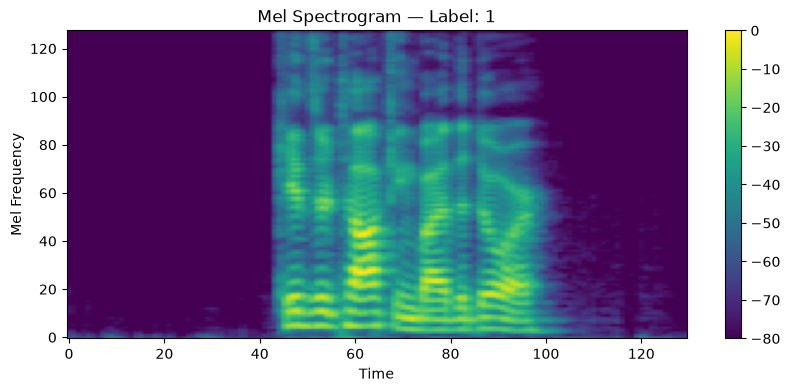

In [25]:
plt.figure(figsize=(10, 4))

plt.imshow(
    mel_batch[0].squeeze(),
    aspect="auto",
    origin="lower"
)

plt.colorbar()

plt.title(f"Mel Spectrogram — Label: {label_batch[0].item()}")

plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

In [26]:
id_to_emotion = {
    0: "neutral",
    1: "happy",
    2: "sad",
    3: "angry",
    4: "fear"
}

In [27]:
print(
    "Emotion:",
    id_to_emotion[label_batch[0].item()]
)

Emotion: happy


In [28]:
from sklearn.model_selection import train_test_split

train_metadata, test_metadata = train_test_split(
    metadata,
    test_size=0.2,
    random_state=42,
    stratify=metadata["emotion"]
)
#stratify is important here because we want the 
#five emotions represented proportionally in both sets.


In [29]:
print("Training samples:", len(train_metadata))
print("Testing samples:", len(test_metadata))

Training samples: 691
Testing samples: 173


In [30]:
print("Training distribution:")
print(train_metadata["emotion"].value_counts())

print("\nTesting distribution:")
print(test_metadata["emotion"].value_counts())

Training distribution:
emotion
fear       154
sad        154
happy      153
angry      153
neutral     77
Name: count, dtype: int64

Testing distribution:
emotion
angry      39
happy      39
sad        38
fear       38
neutral    19
Name: count, dtype: int64


In [31]:
train_dataset = RAVDESSDataset(
    train_metadata,
    label_map
)

test_dataset = RAVDESSDataset(
    test_metadata,
    label_map
)

In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [33]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel batch:", mel_batch.shape)
print("Labels:", label_batch.shape)

Mel batch: torch.Size([32, 1, 128, 130])
Labels: torch.Size([32])


In [34]:
import torch.nn as nn

class EmotionCNN(nn.Module):

    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(

            # First convolution
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            # Second convolution
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
               in_features=32*32*32, out_features=128, bias=True
            ),

            nn.ReLU(),

            nn.Linear(
                in_features=128,
                out_features=num_classes,
                bias=True
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [35]:
model = EmotionCNN()

output = model(mel_batch)

print("Output shape:", output.shape)

Output shape: torch.Size([32, 5])


In [36]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [37]:
epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for mel_batch, label_batch in train_loader:

        # Forward pass
        output = model(mel_batch)

        # Loss
        loss = loss_fn(output, label_batch)

        # Clear gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Loss
        running_loss += loss.item()

        # Accuracy
        predictions = torch.argmax(output, dim=1)

        correct += (predictions == label_batch).sum().item()
        total += label_batch.size(0)

    average_loss = running_loss / len(train_loader)
    accuracy = correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {average_loss:.4f} "
        f"Accuracy: {accuracy*100:.2f}%"
    )

Epoch [1/10] Loss: 33.2659 Accuracy: 20.98%
Epoch [2/10] Loss: 1.5281 Accuracy: 31.69%
Epoch [3/10] Loss: 1.3778 Accuracy: 43.56%
Epoch [4/10] Loss: 1.1852 Accuracy: 52.10%
Epoch [5/10] Loss: 0.9425 Accuracy: 64.25%
Epoch [6/10] Loss: 0.7490 Accuracy: 72.21%
Epoch [7/10] Loss: 0.5889 Accuracy: 79.31%
Epoch [8/10] Loss: 0.4857 Accuracy: 81.91%
Epoch [9/10] Loss: 0.3694 Accuracy: 87.70%
Epoch [10/10] Loss: 0.3118 Accuracy: 90.59%


In [38]:
model.eval()
correct = 0
total = 0

with torch.inference_mode():

    for mel_batch, label_batch in test_loader:

        output = model(mel_batch)

        predictions = torch.argmax(
            output,
            dim=1
        )

        total += label_batch.size(0)

        correct += (
            predictions == label_batch
        ).sum().item()

accuracy = correct / total

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 52.60%


In [39]:
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.inference_mode():

    for mel_batch, label_batch in test_loader:

        output = model(mel_batch)

        predictions = torch.argmax(
            output,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            label_batch.cpu().numpy()
        )

In [40]:
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

In [41]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[10  3  6  0  0]
 [ 1 17  2 11  8]
 [ 3 11 17  1  6]
 [ 1  8  2 22  6]
 [ 1  1  8  3 25]]


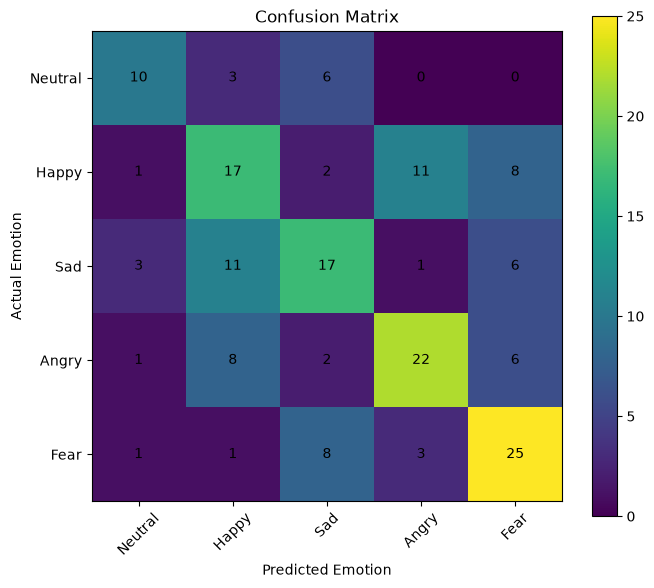

In [42]:
import matplotlib.pyplot as plt

emotion_names = [
    "Neutral",
    "Happy",
    "Sad",
    "Angry",
    "Fear"
]

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(5),
    emotion_names,
    rotation=45
)

plt.yticks(
    range(5),
    emotion_names
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.title("Confusion Matrix")

# Write numbers inside cells
for i in range(5):
    for j in range(5):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [43]:
model.eval()

mel_batch, label_batch = next(iter(train_loader))

with torch.inference_mode():
    output = model(mel_batch)

predictions = torch.argmax(output, dim=1)

print("Labels:")
print(label_batch[:20])

print("\nPredictions:")
print(predictions[:20])

print("\nOutput logits:")
print(output[:3])

print("\nLoss:")
print(loss_fn(output, label_batch).item())

print("\nBatch accuracy:")
print((predictions == label_batch).float().mean().item() * 100)

Labels:
tensor([4, 1, 3, 4, 2, 2, 0, 1, 3, 3, 1, 2, 1, 2, 1, 3, 0, 2, 2, 2])

Predictions:
tensor([4, 1, 3, 4, 2, 2, 0, 1, 3, 3, 1, 2, 1, 2, 1, 3, 0, 4, 2, 2])

Output logits:
tensor([[-1.6209,  2.0932,  0.5487,  1.4512,  3.4771],
        [ 2.2881,  7.6978, -0.0885,  1.7417,  0.8498],
        [-1.8778,  2.9712, -2.2055,  7.6048,  1.0477]])

Loss:
0.23023538291454315

Batch accuracy:
93.75


Now we are doing Actor Independent Train/Test Split to improve accuracy

In [44]:
from sklearn.model_selection import GroupShuffleSplit

# Extract actor number from filepath
metadata["actor"] = metadata["filepath"].apply(
    lambda x: os.path.basename(os.path.dirname(x))
)

# Create actor-independent train/test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        metadata,
        groups=metadata["actor"]
    )
)

train_metadata = metadata.iloc[train_idx].reset_index(drop=True)
test_metadata = metadata.iloc[test_idx].reset_index(drop=True)

print("Training samples:", len(train_metadata))
print("Testing samples:", len(test_metadata))

Training samples: 684
Testing samples: 180


In [45]:
print("Training actors:")
print(sorted(train_metadata["actor"].unique()))

print("\nTesting actors:")
print(sorted(test_metadata["actor"].unique()))

Training actors:
['Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_10', 'Actor_11', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_18', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']

Testing actors:
['Actor_01', 'Actor_09', 'Actor_12', 'Actor_17', 'Actor_19']


In [46]:
overlap = set(train_metadata["actor"]) & set(test_metadata["actor"])

print("Common actors:", overlap)

Common actors: set()


In [47]:
# Create datasets using the actor-independent split

train_dataset = RAVDESSDataset(
    train_metadata,
    label_map
)

test_dataset = RAVDESSDataset(
    test_metadata,
    label_map
)

print("Training dataset:", len(train_dataset))
print("Testing dataset:", len(test_dataset))

Training dataset: 684
Testing dataset: 180


In [48]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [49]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel batch shape:", mel_batch.shape)
print("Label batch shape:", label_batch.shape)

Mel batch shape: torch.Size([32, 1, 128, 130])
Label batch shape: torch.Size([32])


In [50]:
model_actor = EmotionCNN()

loss_fn_actor = nn.CrossEntropyLoss()

optimizer_actor = torch.optim.Adam(
    model_actor.parameters(),
    lr=0.001
)

In [51]:
epochs = 10

for epoch in range(epochs):

    model_actor.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for mel_batch, label_batch in train_loader:

        # Forward pass
        output = model_actor(mel_batch)

        # Calculate loss
        loss = loss_fn_actor(output, label_batch)

        # Clear old gradients
        optimizer_actor.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_actor.step()

        # Track loss
        running_loss += loss.item()

        # Track accuracy
        predictions = torch.argmax(output, dim=1)

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

    average_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {average_loss:.4f} "
        f"Accuracy: {train_accuracy*100:.2f}%"
    )

Epoch [1/10] Loss: 38.8029 Accuracy: 20.03%
Epoch [2/10] Loss: 1.6009 Accuracy: 25.00%
Epoch [3/10] Loss: 1.4244 Accuracy: 39.62%
Epoch [4/10] Loss: 1.0721 Accuracy: 59.36%
Epoch [5/10] Loss: 0.7906 Accuracy: 70.91%
Epoch [6/10] Loss: 0.5208 Accuracy: 81.43%
Epoch [7/10] Loss: 0.3883 Accuracy: 87.72%
Epoch [8/10] Loss: 0.3022 Accuracy: 89.77%
Epoch [9/10] Loss: 0.1492 Accuracy: 96.93%
Epoch [10/10] Loss: 0.1008 Accuracy: 98.54%


In [52]:
model_actor.eval()

correct = 0
total = 0

with torch.inference_mode():

    for mel_batch, label_batch in test_loader:

        output = model_actor(mel_batch)

        predictions = torch.argmax(
            output,
            dim=1
        )

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

test_accuracy_actor = correct / total

print(
    f"Actor-Independent Test Accuracy: "
    f"{test_accuracy_actor * 100:.2f}%"
)

Actor-Independent Test Accuracy: 40.56%


In [53]:
from sklearn.metrics import confusion_matrix

model_actor.eval()

all_predictions = []
all_labels = []

with torch.inference_mode():

    for mel_batch, label_batch in test_loader:

        output = model_actor(mel_batch)

        predictions = torch.argmax(
            output,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            label_batch.cpu().numpy()
        )

cm_actor = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm_actor)

[[ 6  7  7  0  0]
 [ 0 18 13  5  4]
 [ 3 13 20  2  2]
 [ 2  8  6 22  2]
 [ 2 15 11  5  7]]


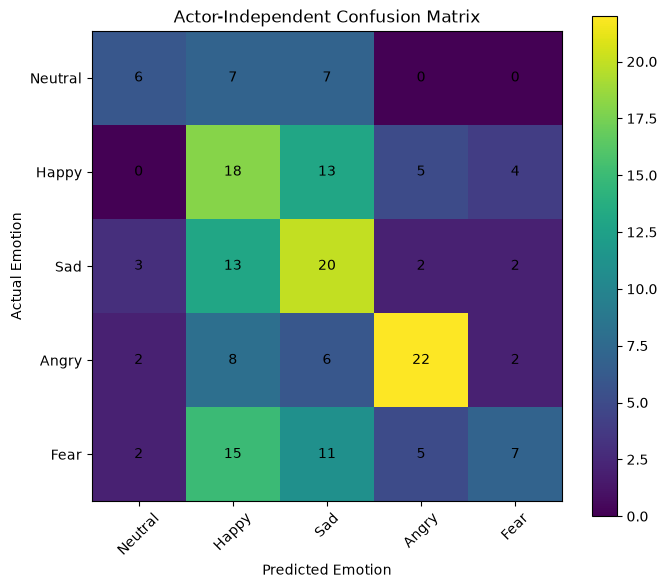

In [54]:
emotion_names = [
    "Neutral",
    "Happy",
    "Sad",
    "Angry",
    "Fear"
]

plt.figure(figsize=(7, 6))

plt.imshow(cm_actor)

plt.colorbar()

plt.xticks(
    range(5),
    emotion_names,
    rotation=45
)

plt.yticks(
    range(5),
    emotion_names
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.title("Actor-Independent Confusion Matrix")

for i in range(5):
    for j in range(5):

        plt.text(
            j,
            i,
            cm_actor[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [55]:
from collections import Counter

class_counts = train_metadata["emotion"].value_counts()

print(class_counts)

emotion
happy      152
sad        152
angry      152
fear       152
neutral     76
Name: count, dtype: int64


Model version 2


In [57]:
import torch

# Keep the order consistent with label_map
class_order = [
    "neutral",
    "happy",
    "sad",
    "angry",
    "fear"
]

counts = torch.tensor(
    [class_counts[emotion] for emotion in class_order],
    dtype=torch.float32
)

class_weights = len(train_metadata) / (
    len(class_order) * counts
)

print("Class weights:", class_weights)

Class weights: tensor([1.8000, 0.9000, 0.9000, 0.9000, 0.9000])


In [58]:
loss_fn_actor_weighted = nn.CrossEntropyLoss(
    weight=class_weights
)

In [59]:
model_weighted = EmotionCNN()

optimizer_weighted = torch.optim.Adam(
    model_weighted.parameters(),
    lr=0.001
)

In [60]:
epochs = 10

for epoch in range(epochs):

    model_weighted.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for mel_batch, label_batch in train_loader:

        # Forward pass
        output = model_weighted(mel_batch)

        # Weighted loss
        loss = loss_fn_actor_weighted(
            output,
            label_batch
        )

        # Clear gradients
        optimizer_weighted.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_weighted.step()

        # Track loss
        running_loss += loss.item()

        # Accuracy
        predictions = torch.argmax(
            output,
            dim=1
        )

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

    average_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {average_loss:.4f} "
        f"Accuracy: {train_accuracy * 100:.2f}%"
    )

Epoch [1/10] Loss: 14.6978 Accuracy: 18.71%
Epoch [2/10] Loss: 1.5958 Accuracy: 22.95%
Epoch [3/10] Loss: 1.5018 Accuracy: 37.13%
Epoch [4/10] Loss: 1.1243 Accuracy: 59.94%
Epoch [5/10] Loss: 0.6436 Accuracy: 78.07%
Epoch [6/10] Loss: 0.4075 Accuracy: 87.87%
Epoch [7/10] Loss: 0.1808 Accuracy: 95.47%
Epoch [8/10] Loss: 0.0761 Accuracy: 98.83%
Epoch [9/10] Loss: 0.0658 Accuracy: 99.27%
Epoch [10/10] Loss: 0.0239 Accuracy: 99.71%


In [61]:
model_weighted.eval()

correct = 0
total = 0

with torch.inference_mode():

    for mel_batch, label_batch in test_loader:

        output = model_weighted(mel_batch)

        predictions = torch.argmax(
            output,
            dim=1
        )

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

weighted_test_accuracy = correct / total

print(
    f"Weighted Test Accuracy: "
    f"{weighted_test_accuracy * 100:.2f}%"
)

Weighted Test Accuracy: 42.22%


In [63]:
from sklearn.metrics import confusion_matrix

model_weighted.eval()

all_predictions_weighted = []
all_labels_weighted = []

with torch.inference_mode():

    for mel_batch, label_batch in test_loader:

        output = model_weighted(mel_batch)

        predictions = torch.argmax(
            output,
            dim=1
        )

        all_predictions_weighted.extend(
            predictions.cpu().numpy()
        )

        all_labels_weighted.extend(
            label_batch.cpu().numpy()
        )

cm_weighted = confusion_matrix(
    all_labels_weighted,
    all_predictions_weighted
)

print(cm_weighted)

[[ 6  0 14  0  0]
 [ 0 17 12  5  6]
 [ 1  8 25  0  6]
 [ 1  5 14 19  1]
 [ 0 15 12  4  9]]


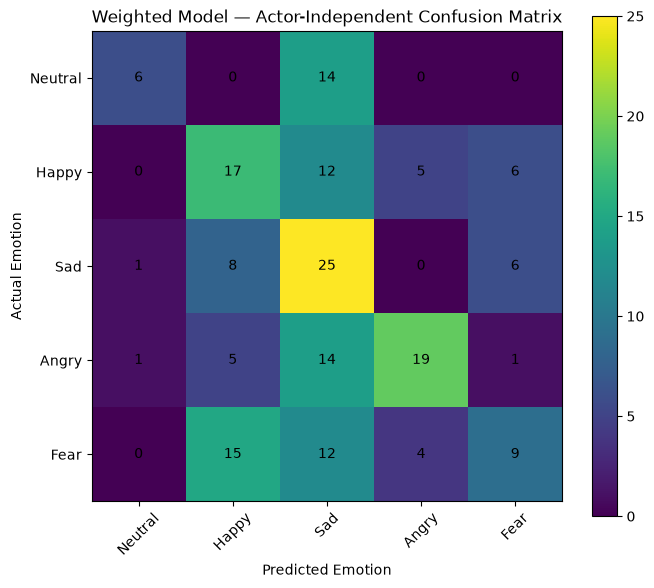

In [64]:
emotion_names = [
    "Neutral",
    "Happy",
    "Sad",
    "Angry",
    "Fear"
]

plt.figure(figsize=(7, 6))

plt.imshow(cm_weighted)

plt.colorbar()

plt.xticks(
    range(5),
    emotion_names,
    rotation=45
)

plt.yticks(
    range(5),
    emotion_names
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.title("Weighted Model — Actor-Independent Confusion Matrix")

for i in range(5):
    for j in range(5):
        plt.text(
            j,
            i,
            cm_weighted[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Model version 3
(Data augmentation+class weights+actor independent)

In [73]:
SAMPLE_RATE = 22050
DURATION = 3
NUM_SAMPLES = SAMPLE_RATE * DURATION


class RAVDESSDataset(Dataset):

    def __init__(self, metadata, label_map, augment=False):
        self.metadata = metadata
        self.label_map = label_map
        self.augment = augment

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):

        # -------------------------
        # Get file and label
        # -------------------------
        audio_path = self.metadata.iloc[index]["filepath"]
        emotion = self.metadata.iloc[index]["emotion"]

        # -------------------------
        # Load audio
        # -------------------------
        signal, sr = librosa.load(
            audio_path,
            sr=SAMPLE_RATE
        )

        # -------------------------
        # Make audio exactly 3 sec
        # -------------------------
        if len(signal) < NUM_SAMPLES:

            signal = np.pad(
                signal,
                (0, NUM_SAMPLES - len(signal))
            )

        else:

            signal = signal[:NUM_SAMPLES]

        # -------------------------
        # Data augmentation
        # ONLY for training
        # -------------------------
        if self.augment:
            noise = np.random.randn(len(signal))
            signal = signal + 0.002 * noise
        # -------------------------
        # Mel Spectrogram
        # -------------------------
        mel = librosa.feature.melspectrogram(
            y=signal,
            sr=sr,
            n_fft=2048,
            hop_length=512,
            n_mels=128
        )

        # -------------------------
        # Convert to dB
        # -------------------------
        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # -------------------------
        # Convert to Tensor
        # [1, 128, 130]
        # -------------------------
        mel_tensor = torch.tensor(
            mel_db,
            dtype=torch.float32
        ).unsqueeze(0)

        # -------------------------
        # Convert label to number
        # -------------------------
        label = self.label_map[emotion]

        return mel_tensor, label

In [74]:
train_dataset_aug = RAVDESSDataset(
    train_metadata,
    label_map,
    augment=True
)

test_dataset_aug = RAVDESSDataset(
    test_metadata,
    label_map,
    augment=False
)

In [75]:
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=32,
    shuffle=True
)

test_loader_aug = DataLoader(
    test_dataset_aug,
    batch_size=32,
    shuffle=False
)

In [76]:
mel_batch, label_batch = next(iter(train_loader_aug))

print("Mel batch:", mel_batch.shape)
print("Labels:", label_batch.shape)

Mel batch: torch.Size([32, 1, 128, 130])
Labels: torch.Size([32])


In [77]:
loss_fn_aug = nn.CrossEntropyLoss(
    weight=class_weights
)

In [78]:
model_aug = EmotionCNN()

optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=0.001
)

In [79]:
epochs = 10

for epoch in range(epochs):

    model_aug.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for mel_batch, label_batch in train_loader_aug:

        # Forward pass
        output = model_aug(mel_batch)

        # Weighted loss
        loss = loss_fn_aug(
            output,
            label_batch
        )

        # Clear gradients
        optimizer_aug.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_aug.step()

        # Track loss
        running_loss += loss.item()

        # Accuracy
        predictions = torch.argmax(
            output,
            dim=1
        )

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

    average_loss = running_loss / len(train_loader_aug)
    train_accuracy = correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {average_loss:.4f} "
        f"Accuracy: {train_accuracy * 100:.2f}%"
    )

Epoch [1/10] Loss: 2.8101 Accuracy: 24.42%
Epoch [2/10] Loss: 1.3822 Accuracy: 48.39%
Epoch [3/10] Loss: 1.1395 Accuracy: 58.33%
Epoch [4/10] Loss: 0.7956 Accuracy: 71.78%
Epoch [5/10] Loss: 0.4756 Accuracy: 82.60%
Epoch [6/10] Loss: 0.2611 Accuracy: 92.98%
Epoch [7/10] Loss: 0.1423 Accuracy: 96.93%
Epoch [8/10] Loss: 0.1299 Accuracy: 96.20%
Epoch [9/10] Loss: 0.0912 Accuracy: 97.22%
Epoch [10/10] Loss: 0.0449 Accuracy: 99.42%


In [80]:
model_aug.eval()

correct = 0
total = 0

with torch.inference_mode():

    for mel_batch, label_batch in test_loader_aug:

        output = model_aug(mel_batch)

        predictions = torch.argmax(
            output,
            dim=1
        )

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

aug_test_accuracy = correct / total

print(
    f"Augmented Test Accuracy: "
    f"{aug_test_accuracy * 100:.2f}%"
)

Augmented Test Accuracy: 34.44%


Model 4(Dropout)

In [82]:
import torch.nn as nn


class EmotionCNNDropout(nn.Module):

    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(

            # Convolution block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            # Convolution block 2
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                32 * 32 * 32,
                128
            ),

            nn.ReLU(),

            # Dropout
            nn.Dropout(
                p=0.5
            ),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [83]:
model_dropout = EmotionCNNDropout()

print(model_dropout)

EmotionCNNDropout(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)


In [84]:
loss_fn_dropout = nn.CrossEntropyLoss(
    weight=class_weights
)

In [85]:
optimizer_dropout = torch.optim.Adam(
    model_dropout.parameters(),
    lr=0.001
)

In [86]:
epochs = 10

for epoch in range(epochs):

    model_dropout.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for mel_batch, label_batch in train_loader:

        # Forward pass
        output = model_dropout(mel_batch)

        # Weighted loss
        loss = loss_fn_dropout(
            output,
            label_batch
        )

        # Clear old gradients
        optimizer_dropout.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_dropout.step()

        # Track loss
        running_loss += loss.item()

        # Training accuracy
        predictions = torch.argmax(
            output,
            dim=1
        )

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

    average_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {average_loss:.4f} "
        f"Accuracy: {train_accuracy * 100:.2f}%"
    )

Epoch [1/10] Loss: 50.2642 Accuracy: 20.61%
Epoch [2/10] Loss: 1.5524 Accuracy: 27.34%
Epoch [3/10] Loss: 1.4852 Accuracy: 32.75%
Epoch [4/10] Loss: 1.4126 Accuracy: 37.13%
Epoch [5/10] Loss: 1.3960 Accuracy: 35.96%
Epoch [6/10] Loss: 1.2977 Accuracy: 43.27%
Epoch [7/10] Loss: 1.2702 Accuracy: 45.61%
Epoch [8/10] Loss: 1.1365 Accuracy: 50.44%
Epoch [9/10] Loss: 1.1107 Accuracy: 52.05%
Epoch [10/10] Loss: 1.0444 Accuracy: 56.87%


In [87]:
model_dropout.eval()

correct = 0
total = 0

with torch.inference_mode():

    for mel_batch, label_batch in test_loader:

        output = model_dropout(mel_batch)

        predictions = torch.argmax(
            output,
            dim=1
        )

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

dropout_test_accuracy = correct / total

print(
    f"Dropout Test Accuracy: "
    f"{dropout_test_accuracy * 100:.2f}%"
)

Dropout Test Accuracy: 36.67%


In [88]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels_weighted,
        all_predictions_weighted,
        target_names=[
            "Neutral",
            "Happy",
            "Sad",
            "Angry",
            "Fear"
        ]
    )
)

              precision    recall  f1-score   support

     Neutral       0.75      0.30      0.43        20
       Happy       0.38      0.42      0.40        40
         Sad       0.32      0.62      0.43        40
       Angry       0.68      0.47      0.56        40
        Fear       0.41      0.23      0.29        40

    accuracy                           0.42       180
   macro avg       0.51      0.41      0.42       180
weighted avg       0.48      0.42      0.42       180

